# Airbnb Madrid: Que factores influyen en el precio y que diferencia a los Superhosts?

**Autora:** Juliana Castano Yarce  
**Fecha:** Mayo 2026  
**Curso:** Programacion y analisis reproducible con datos — Proyecto Final

## 1. Introduccion y Pregunta de Analisis

### Dataset
- **Fuente:** [Inside Airbnb](https://insideairbnb.com/) — un proyecto independiente que recopila datos publicos de Airbnb
- **Ciudad:** Madrid, Espana
- **Fecha de descarga:** 6 de mayo de 2026
- **Tamano:** ~25,000 alojamientos (listings) con 79 variables

### Pregunta de analisis

> **Que factores (barrio, tipo de habitacion, reviews, caracteristicas del host) influyen en el precio de un Airbnb en Madrid, y que diferencia a los Superhosts del resto?**

### Por que es interesante?

Madrid es una de las ciudades mas turisticas de Europa, y Airbnb ha transformado su mercado de alojamiento. Entender que determina el precio y que hace a un buen host puede servir para:

- **Viajeros:** saber si estan pagando un precio justo
- **Hosts:** entender como posicionar mejor su alojamiento
- **La ciudad:** analizar como se distribuye el turismo por barrios

---
## 2. Carga y Exploracion Inicial

In [1]:
# Importar librerias
import pandas as pd       # para trabajar con tablas de datos
import numpy as np        # para operaciones matematicas
import matplotlib.pyplot as plt  # para hacer graficos
import seaborn as sns     # para graficos mas bonitos
import warnings
warnings.filterwarnings('ignore')  # ocultar avisos que no nos afectan

# Configurar estilo visual (colores y fuente de Airbnb)
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Montserrat', 'Arial']
plt.rcParams['text.color'] = '#484848'
plt.rcParams['axes.labelcolor'] = '#484848'
plt.rcParams['xtick.color'] = '#484848'
plt.rcParams['ytick.color'] = '#484848'

# Paleta de colores Airbnb
AIRBNB_ROJO = '#FF5A5F'
AIRBNB_VERDE = '#00A699'
AIRBNB_NARANJA = '#FC642D'
AIRBNB_GRIS = '#484848'
AIRBNB_GRIS_CLARO = '#767676'

In [2]:
# Cargar el dataset
df = pd.read_csv('../data/listings.csv')

# Ver cuantas filas y columnas tiene
print(f"El dataset tiene {df.shape[0]:,} filas y {df.shape[1]} columnas")

El dataset tiene 25,000 filas y 79 columnas


In [3]:
# Ver las primeras 5 filas para hacernos una idea de los datos
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20250914152907,2025-09-15,previous scrape,Bright and airy room,We have a quiet and sunny room with a good vie...,We live in a leafy neighbourhood with plenty o...,https://a0.muscache.com/pictures/68483181/87bc...,83531,...,4.82,4.21,4.67,NaN,f,2,0,2,0,0.25
1,30320,https://www.airbnb.com/rooms/30320,20250914152907,2025-09-15,city scrape,Apartamentos Dana Sol,NaN,NaN,https://a0.muscache.com/pictures/336868/f67409...,130907,...,4.78,4.90,4.69,NaN,t,17,17,0,0,0.93
2,30959,https://www.airbnb.com/rooms/30959,20250914152907,2025-09-15,previous scrape,Beautiful loft in Madrid Center,Beautiful Loft 60m2 size just in the historica...,NaN,https://a0.muscache.com/pictures/78173471/835e...,132883,...,4.63,4.88,4.25,NaN,f,1,1,0,0,0.06
3,40916,https://www.airbnb.com/rooms/40916,20250914152907,2025-09-15,city scrape,Apartasol Apartamentos Dana,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,130907,...,4.81,4.88,4.59,NaN,t,17,17,0,0,0.29
4,62423,https://www.airbnb.com/rooms/62423,20250914152907,2025-09-15,city scrape,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,DISTRICT WITH VERY GOOD VIBES IN THE MIDDLE OF...,https://a0.muscache.com/pictures/miso/Hosting-...,303845,...,4.86,4.97,4.60,NaN,f,3,1,2,0,2.78


In [4]:
# Ver los nombres de las columnas y sus tipos de datos
# object = texto, float64/int64 = numeros
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            25000 non-null  int64  
 1   listing_url                                   25000 non-null  object 
 2   scrape_id                                     25000 non-null  int64  
 3   last_scraped                                  25000 non-null  object 
 4   source                                        25000 non-null  object 
 5   name                                          25000 non-null  object 
 6   description                                   24130 non-null  object 
 7   neighborhood_overview                         10586 non-null  object 
 8   picture_url                                   24999 non-null  object 
 9   host_id                                       25000 non-null 

In [5]:
# Estadisticas basicas de las columnas numericas (promedios, minimos, maximos, etc.)
df.describe().round(2)

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,2.500000e+04,2.500000e+04,2.500000e+04,24903.00,24903.00,25000.00,25000.00,25000.00,18960.00,22488.00,...,19852.00,19852.00,19853.00,19850.00,19849.00,25000.00,25000.00,25000.00,25000.00,19853.00
mean,7.248274e+17,2.025091e+13,2.806729e+08,63.17,75.17,40.42,-3.69,3.17,1.31,1.43,...,4.67,4.73,4.73,4.73,4.53,44.33,37.79,6.42,0.09,1.78
std,5.719092e+17,0.000000e+00,2.200065e+08,153.45,175.20,0.02,0.03,1.92,0.70,0.97,...,0.48,0.46,0.49,0.40,0.54,93.33,90.64,26.73,1.19,2.08
min,2.185300e+04,2.025091e+13,1.745300e+04,1.00,1.00,40.33,-3.83,1.00,0.00,0.00,...,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.01
25%,3.974878e+07,2.025091e+13,6.184860e+07,1.00,2.00,40.41,-3.71,2.00,1.00,1.00,...,4.58,4.68,4.70,4.65,4.43,1.00,0.00,0.00,0.00,0.34
50%,9.026240e+17,2.025091e+13,2.542674e+08,5.00,7.00,40.42,-3.70,3.00,1.00,1.00,...,4.80,4.85,4.88,4.86,4.66,4.00,2.00,0.00,0.00,1.09
75%,1.237047e+18,2.025091e+13,4.690354e+08,34.00,44.00,40.43,-3.68,4.00,1.50,2.00,...,4.94,4.97,4.99,4.97,4.83,25.00,18.00,2.00,0.00,2.63
max,1.508659e+18,2.025091e+13,7.184549e+08,1487.00,2767.00,40.54,-3.55,16.00,19.00,25.00,...,5.00,5.00,5.00,5.00,5.00,407.00,407.00,212.00,29.00,82.94


### Primeras observaciones

- El dataset tiene **25,000 alojamientos** con **79 columnas** — hay mucha informacion disponible
- La mayoria son **apartamentos completos** (~67%), seguidos de **habitaciones privadas** (~32%)
- La columna `price` tiene **~6,000 valores faltantes** — tendremos que limpiar eso en la siguiente seccion
- Algunas columnas como `bedrooms` y `review_scores_rating` tambien tienen valores faltantes
- Hay columnas que estan casi vacias (como `calendar_updated` y `license`) — las podemos ignorar

---
## 3. Limpieza y Transformacion

In [6]:
# Paso 1: Seleccionar solo las columnas que necesitamos
columnas = ['name', 'neighbourhood_cleansed', 'room_type', 'accommodates',
            'bedrooms', 'beds', 'price', 'minimum_nights',
            'number_of_reviews', 'review_scores_rating',
            'host_is_superhost', 'host_response_rate', 'host_total_listings_count',
            'latitude', 'longitude']

df = df[columnas]
print(f"Ahora tenemos {df.shape[1]} columnas en vez de 79")
df.head()

Ahora tenemos 15 columnas en vez de 79


,name,neighbourhood_cleansed,room_type,accommodates,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,host_is_superhost,host_response_rate,host_total_listings_count,latitude,longitude
0,Bright and airy room,Cármenes,Private room,1,NaN,NaN,NaN,4,33,4.58,f,100%,2.0,40.40381,-3.74130
1,Apartamentos Dana Sol,Sol,Entire home/apt,2,1.0,2.0,$157.00,5,173,4.63,f,100%,18.0,40.41476,-3.70418
2,Beautiful loft in Madrid Center,Embajadores,Entire home/apt,2,1.0,NaN,NaN,3,8,4.38,f,NaN,4.0,40.41259,-3.70105
3,Apartasol Apartamentos Dana,Universidad,Entire home/apt,2,1.0,3.0,$143.00,5,53,4.68,f,100%,18.0,40.42247,-3.70577
4,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,Private room,4,1.0,2.0,$65.00,1,249,4.65,f,100%,3.0,40.41884,-3.69655


In [7]:
# Paso 2: Convertir el precio de texto ("$157.00") a numero (157.0)
# Quitamos el signo $ y las comas, y lo convertimos a numero
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'])

print("Ejemplo de precios despues de limpiar:")
print(df['price'].head(10))

Ejemplo de precios despues de limpiar:
0      NaN
1    157.0
2      NaN
3    143.0
4     65.0
5      NaN
6    116.0
7     79.0
8    300.0
9      NaN
Name: price, dtype: float64


In [8]:
# Paso 3: Ver cuantos valores nulos hay por columna
print("Valores nulos por columna:")
print("-" * 40)
print(df.isnull().sum())

Valores nulos por columna:
----------------------------------------
name                            0
neighbourhood_cleansed          0
room_type                       0
accommodates                    0
bedrooms                     2512
beds                         6035
price                        6047
minimum_nights                  0
number_of_reviews               0
review_scores_rating         5147
host_is_superhost             668
host_response_rate           4885
host_total_listings_count      97
latitude                        0
longitude                       0
dtype: int64


In [9]:
# Paso 4: Eliminar filas que no tienen precio (sin precio no podemos analizar nada)
antes = len(df)
df = df.dropna(subset=['price'])
print(f"Filas antes: {antes:,}")
print(f"Filas despues: {len(df):,}")
print(f"Eliminadas: {antes - len(df):,} (no tenian precio)")

Filas antes: 25,000
Filas despues: 18,953
Eliminadas: 6,047 (no tenian precio)


In [10]:
# Paso 5: Convertir host_response_rate de texto ("95%") a numero (95)
df['host_response_rate'] = df['host_response_rate'].str.replace('%', '', regex=False)
df['host_response_rate'] = pd.to_numeric(df['host_response_rate'])

# Convertir host_is_superhost de "t"/"f" a True/False
# "t" = true (si es superhost), "f" = false (no es superhost)
df['host_is_superhost'] = df['host_is_superhost'].map({'t': True, 'f': False})

print("host_response_rate ejemplo:", df['host_response_rate'].head(3).tolist())
print("host_is_superhost ejemplo:", df['host_is_superhost'].head(3).tolist())

host_response_rate ejemplo: [100.0, 100.0, 100.0]
host_is_superhost ejemplo: [False, False, False]


In [11]:
# Paso 6: Eliminar precios extremos que no tienen sentido
# Un Airbnb a $0 es un error, y uno a $10,000/noche no es tipico
antes = len(df)
df = df[(df['price'] > 10) & (df['price'] < 1000)]
print(f"Filas antes: {antes:,}")
print(f"Filas despues: {len(df):,}")
print(f"Eliminadas: {antes - len(df):,} (precios menores a $10 o mayores a $1,000)")
print(f"\nRango de precios final: ${df['price'].min():.0f} - ${df['price'].max():.0f}")

Filas antes: 18,953
Filas despues: 18,845
Eliminadas: 108 (precios menores a $10 o mayores a $1,000)

Rango de precios final: $12 - $999


### Resumen de limpieza

| Paso | Que hicimos | Por que |
|------|-------------|---------|
| 1 | Seleccionar 13 columnas de 79 | Solo necesitamos las relevantes para nuestra pregunta |
| 2 | Convertir precio de texto a numero | `"$157.00"` no se puede usar en calculos |
| 3 | Eliminar filas sin precio | Sin precio no podemos analizar nada |
| 4 | Convertir response rate y superhost | Necesitamos numeros y valores claros, no texto |
| 5 | Eliminar precios extremos (<$10, >$1,000) | Son errores o casos atipicos que distorsionan el analisis |

---
## 4. Analisis Exploratorio (EDA)

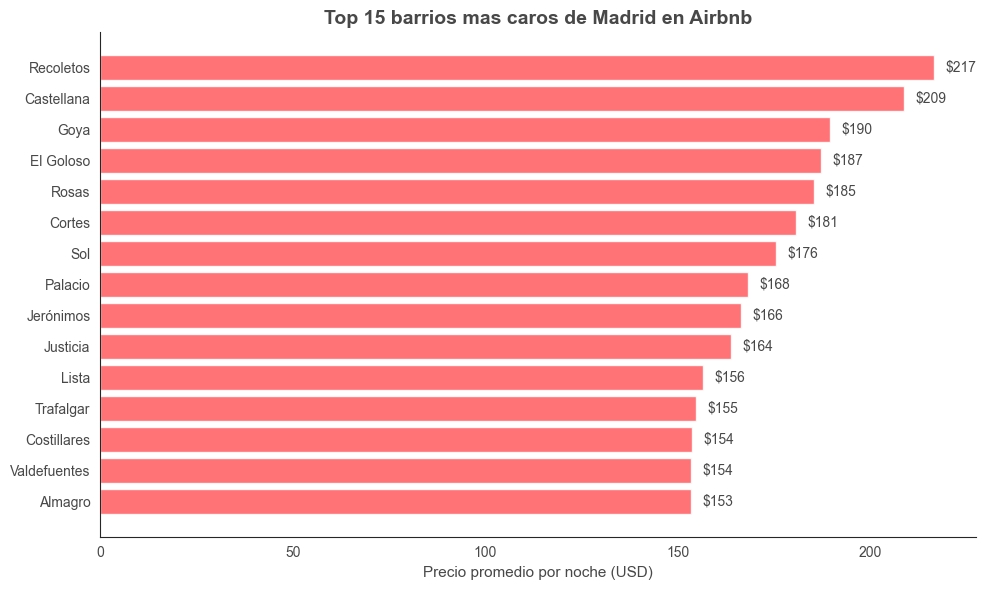

In [12]:
# Grafico 1: Top 15 barrios mas caros de Madrid
# Paso 1: calcular precio promedio por barrio y quedarnos con los 15 mas caros
precio_por_barrio = df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(15)

# Paso 2: crear el grafico
plt.figure(figsize=(10, 6))

# Barras horizontales con el color rojo de Airbnb
plt.barh(precio_por_barrio.index, precio_por_barrio.values, color=AIRBNB_ROJO, alpha=0.85)

# Agregar el precio exacto al lado de cada barra
for i, valor in enumerate(precio_por_barrio.values):
    plt.text(valor + 3, i, f'${valor:.0f}', va='center', fontsize=10, color=AIRBNB_GRIS)

# Titulo centrado
plt.title('Top 15 barrios mas caros de Madrid en Airbnb', fontsize=14, fontweight='bold', loc='center')
plt.xlabel('Precio promedio por noche (USD)', fontsize=11)

# Quitar bordes innecesarios
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretacion:** Los barrios mas caros de Madrid se concentran en la zona centro-norte (Recoletos, Castellana, Goya), con precios promedio que superan los $190/noche. Esto coincide con las zonas mas exclusivas y turisticas de la ciudad.

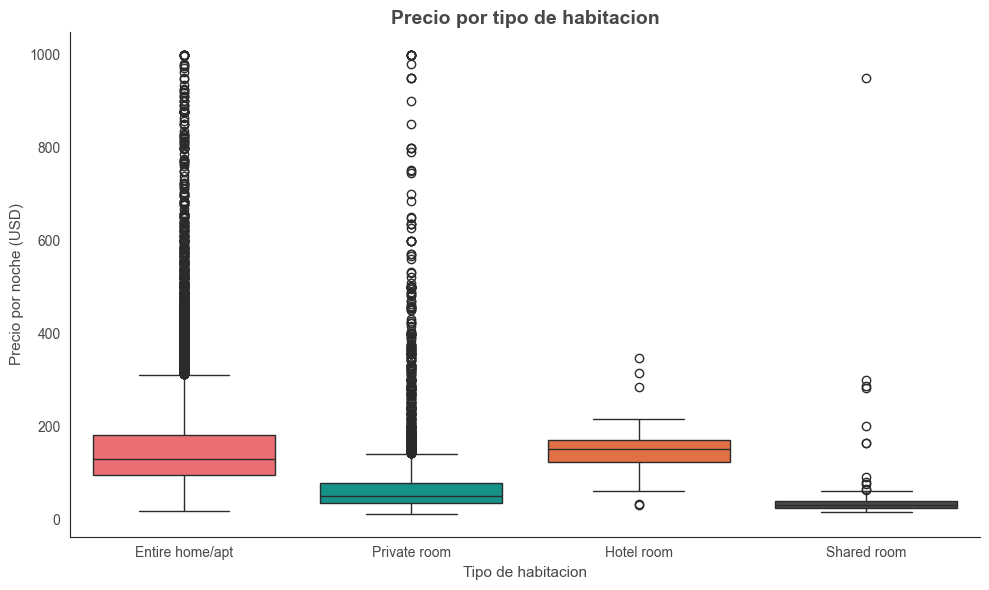

In [13]:
# Grafico 2: Precio por tipo de habitacion
plt.figure(figsize=(10, 6))

# Crear el boxplot - agrupa los precios por tipo de habitacion
sns.boxplot(data=df, x='room_type', y='price',
            palette=[AIRBNB_ROJO, AIRBNB_VERDE, AIRBNB_NARANJA, AIRBNB_GRIS])

plt.title('Precio por tipo de habitacion', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de habitacion', fontsize=11)
plt.ylabel('Precio por noche (USD)', fontsize=11)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretacion:** Un apartamento completo (mediana $129) cuesta mas del doble que una habitacion privada (mediana $50). Los hoteles tienen precios similares a los apartamentos, pero son muy pocos en la plataforma (solo 41 de casi 19,000).

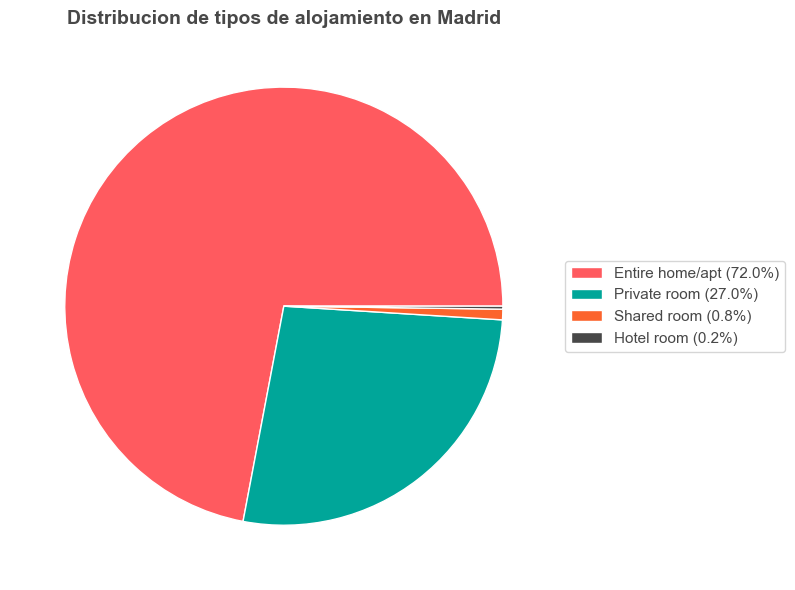

In [14]:
# Grafico 3: Que tipo de alojamiento domina el mercado de Madrid?
plt.figure(figsize=(10, 6))

# Contar cuantos listings hay de cada tipo
conteo = df['room_type'].value_counts()

# Crear etiquetas con nombre + porcentaje para la leyenda
total = conteo.sum()
etiquetas = [f'{nombre} ({valor/total*100:.1f}%)' for nombre, valor in zip(conteo.index, conteo.values)]

# Pie chart limpio — sin texto encima
plt.pie(conteo.values, 
        colors=[AIRBNB_ROJO, AIRBNB_VERDE, AIRBNB_NARANJA, AIRBNB_GRIS])

# Leyenda al lado derecho
plt.legend(etiquetas, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11)

plt.title('Distribucion de tipos de alojamiento en Madrid', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretacion:** El mercado de Airbnb en Madrid esta dominado por apartamentos completos (~72%), seguidos de habitaciones privadas (~27%). Las habitaciones compartidas y hoteles representan menos del 1% cada uno.

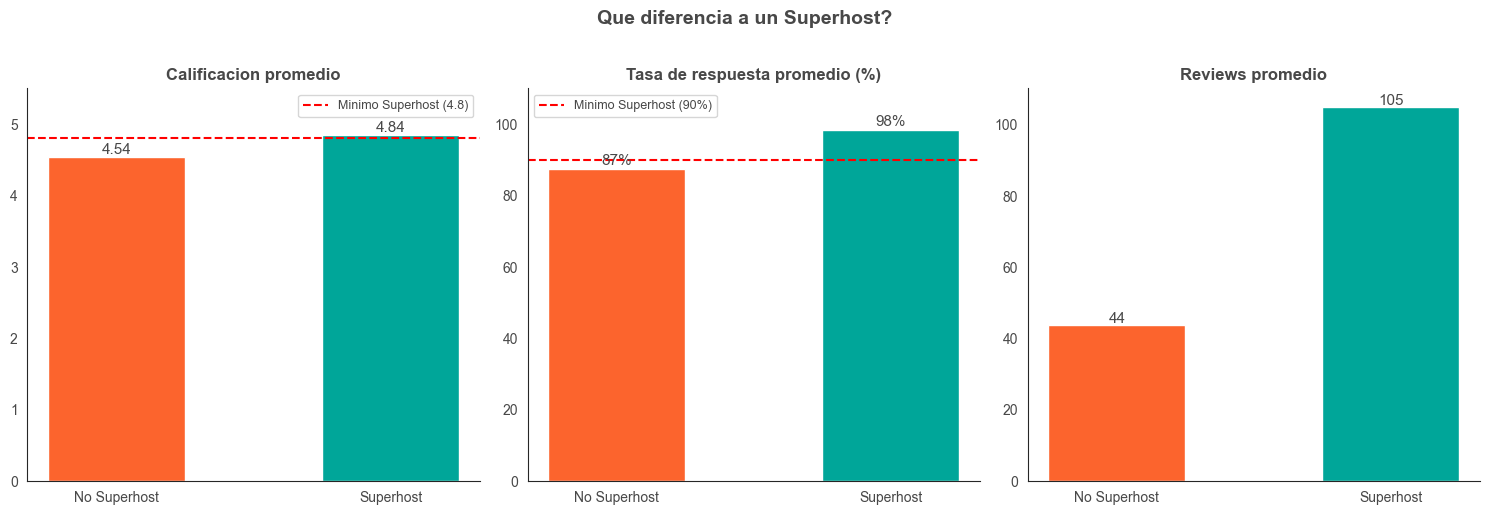

In [15]:
# Grafico 4: Que diferencia a un Superhost? (comparando los 3 criterios que tenemos)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Los colores para cada grupo
colores = [AIRBNB_NARANJA, AIRBNB_VERDE]
nombres = ['No Superhost', 'Superhost']

# --- Grafico 4a: Calificacion promedio ---
cal = df.groupby('host_is_superhost')['review_scores_rating'].mean()
axes[0].bar(nombres, cal.values, color=colores, width=0.5)
axes[0].set_title('Calificacion promedio', fontsize=12, fontweight='bold')
axes[0].axhline(y=4.8, color='red', linestyle='--', label='Minimo Superhost (4.8)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 5.5)
for i, v in enumerate(cal.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11)

# --- Grafico 4b: Tasa de respuesta promedio ---
resp = df.groupby('host_is_superhost')['host_response_rate'].mean()
axes[1].bar(nombres, resp.values, color=colores, width=0.5)
axes[1].set_title('Tasa de respuesta promedio (%)', fontsize=12, fontweight='bold')
axes[1].axhline(y=90, color='red', linestyle='--', label='Minimo Superhost (90%)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 110)
for i, v in enumerate(resp.values):
    axes[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=11)

# --- Grafico 4c: Numero de reviews promedio ---
rev = df.groupby('host_is_superhost')['number_of_reviews'].mean()
axes[2].bar(nombres, rev.values, color=colores, width=0.5)
axes[2].set_title('Reviews promedio', fontsize=12, fontweight='bold')
for i, v in enumerate(rev.values):
    axes[2].text(i, v + 0.5, f'{v:.0f}', ha='center', fontsize=11)

# Quitar bordes de los 3 graficos
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Que diferencia a un Superhost?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretacion:** Los Superhosts se diferencian claramente en los 3 criterios: tienen mejor calificacion, mayor tasa de respuesta y mas reviews (experiencia). Las lineas rojas muestran los minimos que exige Airbnb para obtener ese estatus.

In [16]:
# Grafico 5 (INTERACTIVO): Mapa de Airbnbs en Madrid coloreados por precio
import plotly.express as px

# Tomar una muestra de 3000 para que el mapa no sea muy pesado
muestra = df.sample(n=3000, random_state=42)

# Crear el mapa
fig = px.scatter_mapbox(muestra,
                        lat='latitude',
                        lon='longitude',
                        color='price',
                        size='price',
                        size_max=10,
                        color_continuous_scale=['#00A699', '#FC642D', '#FF5A5F'],
                        hover_data=['name', 'neighbourhood_cleansed', 'room_type', 'price'],
                        labels={'price': 'Precio (USD)',
                                'neighbourhood_cleansed': 'Barrio',
                                'room_type': 'Tipo'},
                        title='Mapa de Airbnbs en Madrid (coloreado por precio)',
                        mapbox_style='open-street-map',
                        zoom=11)

fig.update_layout(height=600)
fig.show()

**Interpretacion:** El mapa muestra que los Airbnbs mas caros (puntos rojos y grandes) se concentran en el centro de Madrid, mientras que las zonas perifericas tienen precios mas bajos (puntos verdes). Al pasar el mouse se puede ver el nombre, barrio, tipo y precio de cada alojamiento.

---
## 5. Analisis Estadistico: Regresion Lineal

Queremos saber **que variables influyen mas en el precio** de un Airbnb en Madrid. Para eso usamos una **regresion lineal** — un modelo que intenta predecir el precio basandose en las caracteristicas del alojamiento.

Es como decirle al modelo: "aqui tienes miles de Airbnbs con su precio, barrio, tipo, camas, calificacion, etc. Aprende la relacion y dime que pesa mas."

In [17]:
# Paso 1: Preparar los datos para el modelo
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Seleccionar las variables que usaremos para predecir el precio
# Convertimos room_type a numeros (el modelo solo entiende numeros)
df_modelo = df[['price', 'accommodates', 'bedrooms', 'beds',
                'number_of_reviews', 'review_scores_rating', 'room_type']].copy()

# Eliminar filas con valores nulos (el modelo no acepta vacios)
df_modelo = df_modelo.dropna()

# Convertir room_type a columnas de 0 y 1 (se llama "one-hot encoding")
# Ej: "Entire home/apt" → columna propia con 1 si es ese tipo, 0 si no
df_modelo = pd.get_dummies(df_modelo, columns=['room_type'], drop_first=True)

print(f"Datos listos: {len(df_modelo):,} filas")
print(f"\nColumnas del modelo:")
print(df_modelo.columns.tolist())

Datos listos: 15,730 filas

Columnas del modelo:
['price', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']


In [18]:
# Paso 2: Dividir datos en entrenamiento y prueba
# Le damos 80% de los datos para que aprenda, y 20% para probar si aprendio bien
X = df_modelo.drop('price', axis=1)  # todo MENOS el precio (las variables que usa para predecir)
y = df_modelo['price']               # el precio (lo que queremos predecir)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos para entrenar: {len(X_train):,}")
print(f"Datos para probar: {len(X_test):,}")

Datos para entrenar: 12,584
Datos para probar: 3,146


In [19]:
# Paso 3: Entrenar el modelo y ver que tan bien predice
modelo = LinearRegression()
modelo.fit(X_train, y_train)  # el modelo "estudia" los datos de entrenamiento

# Hacer predicciones con los datos de prueba
y_pred = modelo.predict(X_test)

# R² = que tan bien predice el modelo (0 = pesimo, 1 = perfecto)
r2 = r2_score(y_test, y_pred)
print(f"R² del modelo: {r2:.3f}")
print(f"\nEsto significa que el modelo explica el {r2*100:.1f}% de la variacion en los precios.")

R² del modelo: 0.349

Esto significa que el modelo explica el 34.9% de la variacion en los precios.


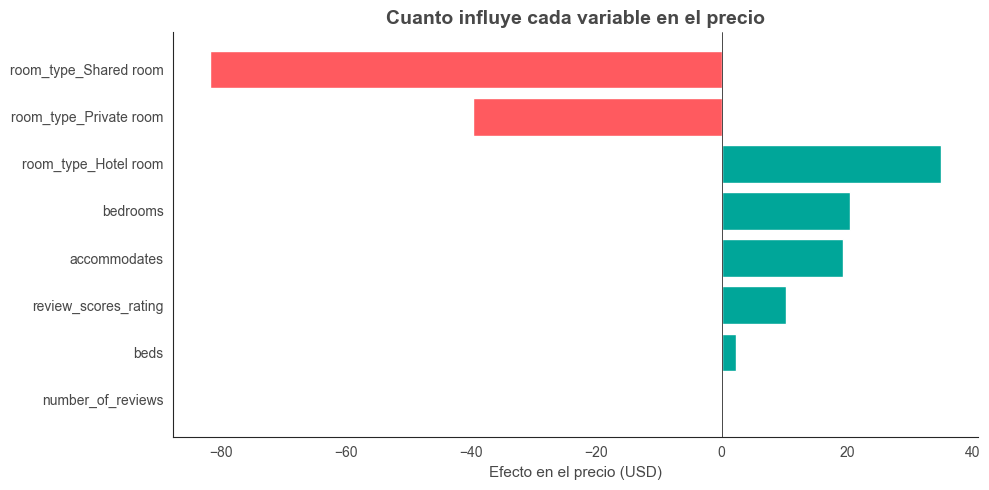


Interpretacion:
  room_type_Shared room: el precio baja $81.7 por cada unidad
  room_type_Private room: el precio baja $39.7 por cada unidad
  room_type_Hotel room: el precio sube $35.1 por cada unidad
  bedrooms: el precio sube $20.5 por cada unidad
  accommodates: el precio sube $19.3 por cada unidad
  review_scores_rating: el precio sube $10.3 por cada unidad
  beds: el precio sube $2.3 por cada unidad
  number_of_reviews: el precio baja $0.0 por cada unidad


In [20]:
# Paso 4: Que variables influyen mas en el precio?
# Los coeficientes nos dicen cuanto sube o baja el precio por cada variable
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

# Grafico de coeficientes
plt.figure(figsize=(10, 5))
colores = [AIRBNB_VERDE if c > 0 else AIRBNB_ROJO for c in coeficientes['Coeficiente']]
plt.barh(coeficientes['Variable'], coeficientes['Coeficiente'], color=colores)

plt.title('Cuanto influye cada variable en el precio', fontsize=14, fontweight='bold')
plt.xlabel('Efecto en el precio (USD)', fontsize=11)
plt.axvline(x=0, color='black', linewidth=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("\nInterpretacion:")
for _, row in coeficientes.iterrows():
    direccion = "sube" if row['Coeficiente'] > 0 else "baja"
    print(f"  {row['Variable']}: el precio {direccion} ${abs(row['Coeficiente']):.1f} por cada unidad")

---
## 6. Documentacion del Uso de IA

Se utilizo **Claude (Anthropic)** como herramienta de consulta durante el proyecto, principalmente para resolver dudas de sintaxis y entender funciones nuevas de Python.

**Como se uso:** La IA sirvio como apoyo tecnico — similar a consultar documentacion o foros. Se le hacian preguntas puntuales sobre funciones de pandas, matplotlib y plotly, y en algunos casos sugirio fragmentos de codigo que luego fueron revisados y adaptados al contexto del analisis.

**Que se corrigio o ajusto:** La IA no siempre entendia el contexto del analisis. En varias ocasiones sus sugerencias necesitaron ajustes en estilo, legibilidad y relevancia analitica antes de ser utiles. Las decisiones sobre que preguntas hacer, que variables usar y como interpretar los resultados fueron completamente propias.

**Reflexion:** La IA es util para acelerar tareas tecnicas y resolver dudas, pero no reemplaza el pensamiento critico. Siempre hay que revisar lo que produce, entender por que funciona, y ajustarlo al objetivo del analisis.

---
## 7. Conclusiones

### Respuesta a la pregunta de analisis

> **Que factores influyen en el precio de un Airbnb en Madrid, y que diferencia a los Superhosts?**

**Sobre el precio por tipo de alojamiento:**

Los datos (de septiembre 2025) muestran una diferencia clara entre tipos de alojamiento:

| Tipo | Precio promedio | Precio mediano |
|------|----------------|----------------|
| Apartamento completo | $158/noche | $129/noche |
| Hotel room | $151/noche | $152/noche |
| Habitacion privada | $75/noche | $50/noche |
| Habitacion compartida | $46/noche | $30/noche |

Un apartamento completo cuesta en promedio **mas del doble** que una habitacion privada y **mas del triple** que una compartida.

**Sobre los barrios:**

Hay una diferencia de casi **5 veces** entre los barrios mas caros y los mas baratos:

- **Barrios mas caros:** Recoletos ($217), Castellana ($209), Goya ($190) — todos en la zona centro-norte de Madrid
- **Barrios de rango medio:** San Diego ($105), Valdeacederas ($102), Casco Historico de Barajas ($101) — zonas residenciales alejadas del centro turistico
- **Barrios mas baratos:** San Cristobal ($46), Horcajo ($45), Vinateros ($40) — zonas perifericas del sur

**Sobre la calificacion y el precio:**

Los alojamientos con calificacion de **4.8 a 5** tienen un precio promedio de **$139/noche**, mientras que los que tienen calificacion menor a 3 promedian **$128/noche**. La diferencia no es enorme, lo que sugiere que la calificacion influye en el precio pero no es el factor principal — el tipo de alojamiento y la ubicacion pesan mucho mas.

**Sobre el modelo de regresion lineal:**

El modelo tiene un R² de **0.349**, lo que significa que las variables que usamos (tipo de habitacion, capacidad, habitaciones, camas, calificacion y reviews) explican el **34.9% de la variacion en precios**. Dicho de forma simple: de cada $100 de diferencia entre un Airbnb y otro, nuestras variables explican ~$35 y los otros ~$65 dependen de cosas que no tenemos en los datos (fotos, decoracion, cercania al metro, temporada, reputacion del host, etc.).

**Sobre los Superhosts:**

Los Superhosts tienen un precio promedio similar al resto ($136 vs $133) — lo que significa que ser Superhost **no permite cobrar mucho mas**. Sin embargo, se diferencian en calidad de servicio: mejor calificacion, mayor tasa de respuesta y mas experiencia (reviews). Ser Superhost es mas un indicador de **calidad** que de **precio**.

### Limitaciones
- **Datos de un solo momento:** Los precios son de septiembre 2025 y pueden variar mucho por temporada (no es lo mismo verano que invierno en Madrid)
- **Factores no medidos:** No tenemos datos sobre calidad de fotos, ubicacion exacta (cercania al metro, atracciones), ni temporada — factores que probablemente explican buena parte del 65% que el modelo no captura
- **Correlacion no es causalidad:** Que los barrios caros tengan precios altos no significa que el barrio "cause" el precio — puede ser la calidad de los apartamentos en esa zona

### Recomendacion
Para alguien que quiera poner su Airbnb en Madrid: el **barrio** y el **tipo de alojamiento** son los factores que mas determinan el precio. Un apartamento completo en Recoletos puede cobrar 5 veces mas que una habitacion compartida en Vinateros. Mas alla de eso, enfocarse en **responder rapido** y **mantener una calificacion alta** (>4.8) ayuda a obtener el estatus de Superhost y genera confianza con los huespedes.